# Preparación del dataset para Power BI

Este notebook toma el archivo original de *Our World in Data*, realiza una transformación inicial y exporta un nuevo CSV listo para usar en **Power BI**.

## Objetivos
- Recortar el rango temporal a **2020–2024**
- Conservar identificadores clave: **country**, **country_code**, **year**
- Transformar la información para tener una columna **sex**
- Dejar las variables educativas como columnas:
  - `primary_education`
  - `lower_secondary_education`
  - `upper_secondary_education`
  - `tertiary_education`

El resultado final será un archivo CSV limpio y estructurado para construir dashboards interactivos.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

## 1. Cargar el archivo original

Ajusta la ruta si cambias de carpeta o de nombre de archivo.


In [2]:
input_path = Path("gender-gap-education-levels/gender-gap-education-levels.csv")
df = pd.read_csv(input_path)

print("Dimensiones originales:", df.shape)
df.head()

Dimensiones originales: (10285, 11)


,Entity,Code,Year,Girls in tertiary education,Boys in tertiary education,Girls in primary education,Boys in primary education,Boys in lower secondary education,Girls in lower secondary education,Boys in upper secondary education,Girls in upper secondary education
0,Afghanistan,AFG,1820,0.0,0.01,0.0,0.01,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,1825,0.0,0.01,0.0,0.01,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,1830,0.0,0.01,0.0,0.01,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,1835,0.0,0.01,0.0,0.01,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,1840,0.0,0.01,0.0,0.01,NaN,NaN,NaN,NaN


## 2. Inspección rápida de columnas y rango temporal

In [3]:
print(df.columns.tolist())
print("Año mínimo:", df["Year"].min())
print("Año máximo:", df["Year"].max())

['Entity', 'Code', 'Year', 'Girls in tertiary education', 'Boys in tertiary education', 'Girls in primary education', 'Boys in primary education', 'Boys in lower secondary education', 'Girls in lower secondary education', 'Boys in upper secondary education', 'Girls in upper secondary education']
Año mínimo: 1820
Año máximo: 2024


## 3. Recortar a los años 1998–2024

In [4]:
df = df[df["Year"].between(1998, 2024)].copy()

print("Dimensiones después del recorte temporal:", df.shape)
df[["Entity", "Code", "Year"]].head()

Dimensiones después del recorte temporal: (4622, 11)


,Entity,Code,Year
37,Afghanistan,AFG,2003
38,Afghanistan,AFG,2004
39,Afghanistan,AFG,2007
40,Afghanistan,AFG,2009
41,Afghanistan,AFG,2011


## 4. Renombrar columnas clave

Vamos a usar nombres más cómodos para el flujo en Power BI.


In [5]:
df = df.rename(columns={
    "Entity": "country",
    "Code": "country_code",
    "Year": "year"
})

df.head()

,country,country_code,year,Girls in tertiary education,Boys in tertiary education,Girls in primary education,Boys in primary education,Boys in lower secondary education,Girls in lower secondary education,Boys in upper secondary education,Girls in upper secondary education
37,Afghanistan,AFG,2003,0.57395,2.15839,NaN,NaN,NaN,NaN,NaN,NaN
38,Afghanistan,AFG,2004,0.57760,2.17154,NaN,NaN,NaN,NaN,NaN,NaN
39,Afghanistan,AFG,2007,NaN,NaN,NaN,NaN,NaN,NaN,27.36805,10.12806
40,Afghanistan,AFG,2009,1.48238,6.46330,NaN,NaN,NaN,NaN,NaN,NaN
41,Afghanistan,AFG,2011,1.86354,5.56672,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Pasar de formato ancho a formato largo

Las columnas originales combinan dos dimensiones al mismo tiempo:
- el **sexo** (`Girls` / `Boys`)
- el **nivel educativo**

Primero las convertimos a una sola columna de indicadores.


In [6]:
id_cols = ["country", "country_code", "year"]
value_cols = [c for c in df.columns if c not in id_cols]

long_df = df.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name="indicator",
    value_name="value"
)

print("Dimensiones en formato largo:", long_df.shape)
long_df.head()

Dimensiones en formato largo: (36976, 5)


,country,country_code,year,indicator,value
0,Afghanistan,AFG,2003,Girls in tertiary education,0.57395
1,Afghanistan,AFG,2004,Girls in tertiary education,0.57760
2,Afghanistan,AFG,2007,Girls in tertiary education,NaN
3,Afghanistan,AFG,2009,Girls in tertiary education,1.48238
4,Afghanistan,AFG,2011,Girls in tertiary education,1.86354


## 6. Extraer la columna `sex` y el nivel educativo

A partir del texto de cada indicador separamos:
- `sex`
- `education_level`


In [7]:
extracted = long_df["indicator"].str.extract(r"^(Girls|Boys) in (.*)$")
long_df["sex"] = extracted[0].str.lower()
long_df["education_level"] = extracted[1]

long_df[["indicator", "sex", "education_level"]].head(10)

,indicator,sex,education_level
0,Girls in tertiary education,girls,tertiary education
1,Girls in tertiary education,girls,tertiary education
2,Girls in tertiary education,girls,tertiary education
3,Girls in tertiary education,girls,tertiary education
4,Girls in tertiary education,girls,tertiary education
5,Girls in tertiary education,girls,tertiary education
6,Girls in tertiary education,girls,tertiary education
7,Girls in tertiary education,girls,tertiary education
8,Girls in tertiary education,girls,tertiary education
9,Girls in tertiary education,girls,tertiary education


## 7. Reorganizar para dejar una fila por país, año y sexo

El objetivo final es tener esta estructura:

- `country`
- `country_code`
- `year`
- `sex`
- `primary_education`
- `lower_secondary_education`
- `upper_secondary_education`
- `tertiary_education`


In [8]:
powerbi_df = (
    long_df
    .pivot(
        index=["country", "country_code", "year", "sex"],
        columns="education_level",
        values="value"
    )
    .reset_index()
)
powerbi_df=powerbi_df.rename_axis(None, axis=1)
powerbi_df.head()

,country,country_code,year,sex,lower secondary education,primary education,tertiary education,upper secondary education
0,Afghanistan,AFG,2003,boys,NaN,NaN,2.15839,NaN
1,Afghanistan,AFG,2003,girls,NaN,NaN,0.57395,NaN
2,Afghanistan,AFG,2004,boys,NaN,NaN,2.17154,NaN
3,Afghanistan,AFG,2004,girls,NaN,NaN,0.57760,NaN
4,Afghanistan,AFG,2007,boys,NaN,NaN,NaN,27.36805


## 8. Limpiar nombres de columnas

In [9]:
powerbi_df = powerbi_df.rename(columns={
    "primary education": "primary_education",
    "lower secondary education": "lower_secondary_education",
    "upper secondary education": "upper_secondary_education",
    "tertiary education": "tertiary_education",
})

column_order = [
    "country",
    "country_code",
    "year",
    "sex",
    "primary_education",
    "lower_secondary_education",
    "upper_secondary_education",
    "tertiary_education",
]

powerbi_df = powerbi_df[column_order].sort_values(
    ["country", "year", "sex"]
).reset_index(drop=True)

print("Dimensiones finales:", powerbi_df.shape)
powerbi_df.head(12)

Dimensiones finales: (9244, 8)


,country,country_code,year,sex,primary_education,lower_secondary_education,upper_secondary_education,tertiary_education
0,Afghanistan,AFG,2003,boys,NaN,NaN,NaN,2.15839
1,Afghanistan,AFG,2003,girls,NaN,NaN,NaN,0.57395
2,Afghanistan,AFG,2004,boys,NaN,NaN,NaN,2.17154
3,Afghanistan,AFG,2004,girls,NaN,NaN,NaN,0.57760
4,Afghanistan,AFG,2007,boys,NaN,NaN,27.36805,NaN
5,Afghanistan,AFG,2007,girls,NaN,NaN,10.12806,NaN
6,Afghanistan,AFG,2009,boys,NaN,NaN,NaN,6.46330
7,Afghanistan,AFG,2009,girls,NaN,NaN,NaN,1.48238
8,Afghanistan,AFG,2011,boys,NaN,NaN,NaN,5.56672
9,Afghanistan,AFG,2011,girls,NaN,NaN,NaN,1.86354


## 9. Revisar valores faltantes

Esto es útil antes de llevar el archivo a Power BI.


In [10]:
powerbi_df.isna().sum().sort_values(ascending=False)

lower_secondary_education    3724
primary_education            3168
upper_secondary_education    2826
tertiary_education           2612
country_code                  422
sex                             0
country                         0
year                            0
dtype: int64

## 10. Exportar el nuevo dataset para Power BI

In [11]:
output_path = Path("gender-gap-education-levels/gender_gap_education_2020_2024_powerbi.csv")
powerbi_df.to_csv(output_path, index=False)

print(f"Archivo exportado en: {output_path.resolve()}")

Archivo exportado en: /home/neno/Downloads/gender-gap-education-levels/gender_gap_education_2020_2024_powerbi.csv


## 11. Sugerencia para Power BI

Con este archivo ya puedes construir fácilmente:
- filtros por `country`, `year` y `sex`
- tarjetas por nivel educativo
- gráficos de líneas para evolución temporal
- comparaciones entre niñas y niños
- barras de brecha por nivel educativo

Una métrica simple y útil en Power BI sería, por ejemplo:

**Brecha primaria = girls - boys**  
o, si prefieres, una comparación porcentual entre ambos grupos.


In [12]:
import matplotlib.pyplot as plt

In [13]:
# Filtrar World
world = powerbi_df[powerbi_df["country"] == "World"].copy()
world = world.sort_values("year").set_index("year")

In [14]:
world

,country,country_code,sex,primary_education,lower_secondary_education,upper_secondary_education,tertiary_education
year,,,,,,,
1998,World,OWID_WRL,boys,86.02509,76.42147,53.07424,17.66999
1998,World,OWID_WRL,girls,80.50624,71.43559,46.17226,17.22482
1999,World,OWID_WRL,boys,87.04495,76.63228,53.31900,18.42866
1999,World,OWID_WRL,girls,81.59559,71.56361,46.36791,18.24185
2000,World,OWID_WRL,boys,87.43674,77.59571,53.77132,19.11030
2000,World,OWID_WRL,girls,82.25411,72.65160,47.32390,19.08234
2001,World,OWID_WRL,boys,88.57769,78.93010,55.07952,19.92734
2001,World,OWID_WRL,girls,83.61177,74.53226,49.35876,20.00786
2002,World,OWID_WRL,boys,88.65255,79.52142,55.64169,20.87109


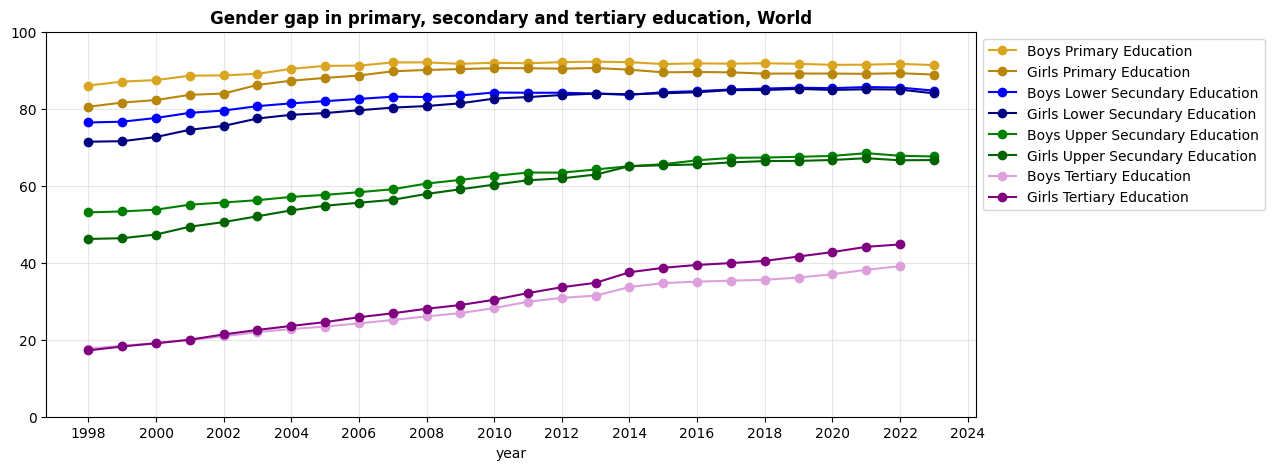

In [17]:
plt.figure(figsize=(12,5))
world[world["sex"]=="boys"]["primary_education"].plot(marker="o",color="goldenrod",label="Boys Primary Education")
world[world["sex"]=="girls"]["primary_education"].plot(marker="o",color="darkgoldenrod",label="Girls Primary Education")
world[world["sex"]=="boys"]["lower_secondary_education"].plot(marker="o",color="blue",label="Boys Lower Secundary Education")
world[world["sex"]=="girls"]["lower_secondary_education"].plot(marker="o",color="navy",label="Girls Lower Secundary Education")
world[world["sex"]=="boys"]["upper_secondary_education"].plot(marker="o",color="green",label="Boys Upper Secundary Education")
world[world["sex"]=="girls"]["upper_secondary_education"].plot(marker="o",color="darkgreen",label="Girls Upper Secundary Education")
world[world["sex"]=="boys"]["tertiary_education"].plot(marker="o",color="plum",label="Boys Tertiary Education")
world[world["sex"]=="girls"]["tertiary_education"].plot(marker="o",color="purple",label="Girls Tertiary Education")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.ylim(0,100); plt.xticks(np.arange(1998,2025,2))
plt.grid(alpha=0.3)
plt.title("Gender gap in primary, secondary and tertiary education, World", fontweight="bold")
plt.show()